# Validação 22 — Busca federada e deduplicação científica

## tl;dr

Este experimento controlado combina PubMed, OpenAlex e SciELO via OpenAlex. Dez registros brutos são reduzidos a seis trabalhos únicos; quatro possuem PMID e podem seguir imediatamente para o processamento atual. A federação acrescenta três trabalhos ao conjunto único do PubMed, enquanto a deduplicação impede que o mesmo artigo seja contado várias vezes.

O resultado valida as regras de integração, identidade, proveniência e tolerância a falhas. Ele **não mede recall clínico** nem demonstra que as primeiras posições recuperadas sejam as melhores para uma alegação real.

## Context & Methods

O pipeline anterior pesquisava apenas no PubMed. Esta etapa cria uma entidade canônica de trabalho científico, preserva as posições em cada fonte, agrupa duplicatas por DOI, PMID ou pela combinação exata normalizada de título, ano e primeiro autor, e aplica Reciprocal Rank Fusion (RRF) às posições.

### Key Assumptions

- PubMed é priorizado ao escolher metadados porque o fluxo atual de conteúdo depende de PMID e PMC.
- SciELO é consultado tematicamente pela lista oficial `scielo` do OpenAlex (`primary_location.source.listed_in:scielo`). A origem indireta permanece explícita.
- Trabalhos sem PMID são preservados, mas não são enviados ao recuperador PMC como se tivessem um identificador PubMed.
- Os dados abaixo são controlados e determinísticos. O teste serve para validar o software, não a cobertura das bases.

Referências técnicas: [OpenAlex Works](https://help.openalex.org/api/), [listas de fontes do OpenAlex](https://help.openalex.org/data/source-lists/) e [PubMed E-utilities](https://www.ncbi.nlm.nih.gov/books/NBK25499/).

## Data

### 1. Preparar o experimento controlado

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from fatofake import (
    FederatedSearchEngine,
    ProviderSearchResult,
    ScientificWork,
    SearchPlan,
    SourceRank,
)

QUERY_1 = "coffee consumption prostate cancer"
QUERY_2 = "coffee prostate neoplasm risk"
PLAN = SearchPlan(
    claim="O consumo de café altera o risco de câncer de próstata.",
    queries=(QUERY_1, QUERY_2),
)

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

### 2. Definir candidatos com sobreposição conhecida

O conjunto contém duplicatas por DOI entre fontes, repetição do mesmo PMID entre consultas e dois trabalhos externos sem PMID. Assim, sabemos antecipadamente quais agrupamentos são corretos.

In [2]:
def candidate(source, identifier, title, *, doi=None, pmid=None, author="Silva A", year="2024", query=QUERY_1, rank=1):
    return ScientificWork(
        title=title,
        authors=(author,),
        journal="Periódico controlado",
        publication_date=year,
        doi=doi,
        pmid=pmid,
        url=f"https://example.org/{identifier}",
        matched_queries=(query,),
        sources=(source,),
        source_ids=((source, identifier),),
        source_ranks=(SourceRank(source, query, rank),),
    )


class ControlledProvider:
    def __init__(self, name, records_by_query):
        self.name = name
        self.records_by_query = records_by_query

    def search(self, query, *, max_results):
        records = tuple(self.records_by_query.get(query, ()))[:max_results]
        return ProviderSearchResult(self.name, query, len(records), records)


pubmed = ControlledProvider("PubMed", {
    QUERY_1: (
        candidate("PubMed", "101", "Coffee consumption and prostate cancer", doi="10.1000/a", pmid="101", rank=1),
        candidate("PubMed", "202", "Coffee and prostate cancer: systematic review", doi="10.1000/b", pmid="202", author="Costa B", rank=2),
    ),
    QUERY_2: (
        candidate("PubMed", "101", "Coffee consumption and prostate cancer", doi="10.1000/a", pmid="101", query=QUERY_2, rank=1),
        candidate("PubMed", "303", "Coffee intake in a prospective cohort", doi="10.1000/c", pmid="303", author="Souza C", query=QUERY_2, rank=2),
    ),
})

openalex = ControlledProvider("OpenAlex", {
    QUERY_1: (
        candidate("OpenAlex", "W1", "Coffee consumption and prostate cancer", doi="https://doi.org/10.1000/A", rank=1),
        candidate("OpenAlex", "W4", "Coffee compounds and prostate cells", doi="10.1000/d", author="Lima D", rank=2),
    ),
    QUERY_2: (
        candidate("OpenAlex", "W2", "Coffee and prostate cancer: systematic review", doi="10.1000/b", pmid="202", author="Costa B", query=QUERY_2, rank=1),
        candidate("OpenAlex", "W5", "Dietary patterns and prostate outcomes", doi="10.1000/e", pmid="404", author="Rocha E", query=QUERY_2, rank=2),
    ),
})

scielo = ControlledProvider("SciELO (via OpenAlex)", {
    QUERY_1: (
        candidate("SciELO (via OpenAlex)", "S4", "Coffee compounds and prostate cells", doi="10.1000/d", author="Lima D", rank=1),
        candidate("SciELO (via OpenAlex)", "S6", "Café e saúde da próstata", doi="10.1000/f", author="Pereira F", rank=2),
    ),
    QUERY_2: (),
})

engine = FederatedSearchEngine((pubmed, openalex, scielo))
result = engine.search(PLAN, max_results_per_query=5)

## Results

### 3. Inspecionar o conjunto deduplicado e sua proveniência

In [3]:
rows = []
for item in result.works:
    rows.append(
        "<tr>"
        f"<td>{item.title}</td>"
        f"<td>{item.doi or '—'}</td>"
        f"<td>{item.pmid or '—'}</td>"
        f"<td>{', '.join(item.sources)}</td>"
        f"<td>{item.retrieval_score:.4f}</td>"
        "</tr>"
    )

display(HTML(
    "<table><thead><tr>"
    "<th>Trabalho canônico</th><th>DOI</th><th>PMID</th><th>Fontes</th><th>RRF</th>"
    "</tr></thead><tbody>" + "".join(rows) + "</tbody></table>"
))

Trabalho canônico,DOI,PMID,Fontes,RRF
Coffee consumption and prostate cancer,10.1000/a,101,"PubMed, OpenAlex",0.0492
Coffee and prostate cancer: systematic review,10.1000/b,202,"PubMed, OpenAlex",0.0325
Coffee compounds and prostate cells,10.1000/d,—,"OpenAlex, SciELO (via OpenAlex)",0.0325
Coffee intake in a prospective cohort,10.1000/c,303,PubMed,0.0161
Dietary patterns and prostate outcomes,10.1000/e,404,OpenAlex,0.0161
Café e saúde da próstata,10.1000/f,—,SciELO (via OpenAlex),0.0161


Os artigos `10.1000/a`, `10.1000/b` e `10.1000/d` aparecem em mais de um registro, mas cada um ocupa apenas uma linha canônica. As fontes e posições originais continuam armazenadas, permitindo auditar por que cada trabalho foi selecionado.

### 4. Comparar cobertura bruta, única e processável

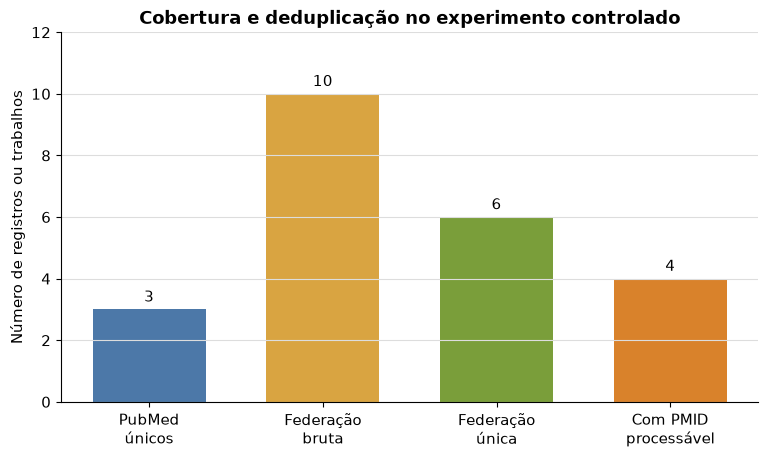

{'registros_brutos': 10,
 'trabalhos_unicos': 6,
 'duplicatas_consolidadas': 4,
 'trabalhos_com_pmid': 4,
 'trabalhos_sem_pmid': 2,
 'ganho_unico_sobre_pubmed': 3}

In [4]:
raw_by_source = {
    item.source: sum(
        query_result.retrieved_count
        for query_result in result.query_results
        if query_result.source == item.source
    )
    for item in result.query_results
}
pubmed_unique = len({item.pmid for item in result.works if "PubMed" in item.sources})

labels = [
    "PubMed\núnicos",
    "Federação\nbruta",
    "Federação\núnica",
    "Com PMID\nprocessável",
]
values = [
    pubmed_unique,
    sum(raw_by_source.values()),
    len(result.works),
    len(result.publications),
]
colors = ["#4C78A8", "#D9A441", "#7A9E3A", "#D9822B"]

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=colors, width=0.65)
ax.set_title("Cobertura e deduplicação no experimento controlado")
ax.set_ylabel("Número de registros ou trabalhos")
ax.set_ylim(0, max(values) + 2)
ax.grid(axis="y", color="#dddddd", linewidth=0.8)
ax.bar_label(bars, padding=3)
display(
    fig,
    metadata={
        "image/png": {
            "alt": (
                "Gráfico de barras: PubMed tem 3 trabalhos únicos, a federação "
                "produz 10 registros brutos, 6 trabalhos únicos e 4 com PMID."
            )
        }
    },
)
plt.close(fig)

summary = {
    "registros_brutos": sum(raw_by_source.values()),
    "trabalhos_unicos": len(result.works),
    "duplicatas_consolidadas": sum(raw_by_source.values()) - len(result.works),
    "trabalhos_com_pmid": len(result.publications),
    "trabalhos_sem_pmid": len(result.unresolved_works),
    "ganho_unico_sobre_pubmed": len(result.works) - pubmed_unique,
}
display(summary)

O ranking não soma scores incompatíveis das APIs. Cada aparição contribui apenas com sua posição por RRF. Um trabalho presente em várias fontes ou consultas recebe mais sinal, sem ser contado como evidência independente.

## Checks

As verificações abaixo fazem o notebook falhar se a deduplicação, a elegibilidade por PMID ou a proveniência regredirem.

In [5]:
assert summary == {
    "registros_brutos": 10,
    "trabalhos_unicos": 6,
    "duplicatas_consolidadas": 4,
    "trabalhos_com_pmid": 4,
    "trabalhos_sem_pmid": 2,
    "ganho_unico_sobre_pubmed": 3,
}
assert len({item.doi for item in result.works}) == 6
assert next(item for item in result.works if item.doi == "10.1000/a").sources == ("PubMed", "OpenAlex")
assert all(item.pmid for item in result.publications)
assert all(item.pmid is None for item in result.unresolved_works)
assert result.failures == ()

print("Validação concluída: deduplicação, ranking, proveniência e elegibilidade preservados.")

Validação concluída: deduplicação, ranking, proveniência e elegibilidade preservados.


## Takeaways

- A busca federada amplia o conjunto candidato sem inflar a quantidade de evidências com cópias do mesmo artigo.
- DOI e PMID são as chaves fortes; título, ano e primeiro autor formam apenas um fallback conservador.
- Resultados SciELO mantêm a indicação `via OpenAlex`, evitando atribuir ao ArticleMeta uma busca temática que ele não fornece.
- Trabalhos sem PMID não são descartados: ficam auditáveis e aguardam um adaptador de conteúdo por DOI/editora.
- A próxima validação deve usar um conjunto prata de consultas e julgamentos de relevância para calcular `Recall@K`, `Precision@K`, MRR e ganho real de cobertura.